# 3 — Cross-Validation, Plotting, and Thresholding

Three things, in order:

1. **Score the entire dataset** by k-fold cross-validation, so every
   product gets a prediction from a model that never saw it.
2. **Plot** the results overall and by segment — by hierarchy level and by
   confidence bucket.
3. **Set thresholds** for a multi-level predictor: emit the deepest level
   whose confidence clears its bar, and truncate rather than guess below
   it.

Every score here is a **raw, uncalibrated** probability — the product of
the per-level posteriors, summed over paths sharing the prefix.

Thresholds can be chosen two ways, and both are included: hit an accuracy
standard, or minimise cost. Pick one at the top of section 3.

## Setup

In [0]:
%load_ext autoreload
%autoreload 2

In [0]:
import json
import os
import sys

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd

from product_classifier import PipelineConfig, data as data_mod, paths
from product_classifier.gridsearch import apply_saved_params

# cross-validation
from product_classifier.crossval import (
    out_of_fold_predictions, crossfit_accuracy, crossfit_cost, savings_summary,
)
from product_classifier.repeated_holdout import (
    repeated_holdout, bucket_accuracy_by_level, bucket_stats,
    level_bucket_summary, plot_bucket_violins, plot_bucket_violins_by_level,
)

# thresholds and per-item output
from product_classifier.cascade import (
    tune_thresholds, apply_cascade, cascade_report, prefix_correct,
    per_item_table, outcome_summary,
)
from product_classifier.costing import CostModel
from product_classifier.cost_thresholds import (
    implied_thresholds, implied_accuracy_targets, cost_optimal_thresholds,
    compare_threshold_policies, sweep_error_cost,
)

# plotting
from product_classifier.plotting import (
    plot_accuracy_by_bucket, plot_coverage_curve,
    plot_accuracy_by_bucket_grid, plot_coverage_curve_grid,
    plot_per_level_accuracy, plot_top_confusions,
)
from product_classifier.evaluation import (
    build_comparison, top_confusions, per_level_accuracy, prefix_accuracy,
    path_accuracy,
)

---
## 1. Config

Settings come from notebook 2's saved record, so nothing is retyped.

In [0]:
cfg = PipelineConfig()

cfg.data.path = paths.data_path("cleaned_data.txt")
cfg.data.file_format = "csv"
cfg.data.delimiter = "|"
cfg.data.text_col = "FullDesc"
cfg.data.id_col = "Vallen ID"
cfg.data.level_columns = [
    "Level 1 ID",
    "Level 2 ID",
    "Level 3 ID",
    "Level 4 ID",
]

cfg.model.vectorizer.max_features = 75_000
cfg.model.vectorizer.min_df = 2
cfg.split.min_path_count = 5
cfg.model.vectorizer.ngram_range = (1, 2)

cfg.model.n_levels = 4
cfg.model.nb.alpha = 0.001
cfg.model.vectorizer.max_df = 0.95
cfg.model.vectorizer.stop_words = "english"
cfg.model.vectorizer.kind = "tfidf"
cfg.model.vectorizer.sublinear_tf = True
cfg.model.vectorizer.norm = "l2"
cfg.model.vectorizer.use_idf = False
cfg.model.vectorizer.binary = True
# Fold each bigram to its sorted form, so "ball valve" and "valve ball"
# are one feature. Only bigrams; unigrams and trigrams keep their order.
cfg.model.vectorizer.unordered_bigrams = False
cfg.model.nb.fit_prior = True
cfg.model.prediction_mode = "conditional_path"


# Raw scores everywhere. Without this the prefix probabilities come back
# normalised, and a raw threshold compared against a normalised score is
# comparing two different quantities.
cfg.model.normalise_probabilities = False

PARAMS_PATH = "../outputs/best_params.json"
if os.path.exists(PARAMS_PATH):
    cfg, _record = apply_saved_params(cfg, PARAMS_PATH)
else:
    print(f"no {PARAMS_PATH} — using the defaults above. Run notebook 2 first")
    print("if you want the searched settings.")

levels = cfg.active_levels()
cfg.model

no ../outputs/best_params.json — using the defaults above. Run notebook 2 first
if you want the searched settings.


ModelConfig(n_levels=4, prediction_mode='conditional_path', normalise_probabilities=False, batch_size=2000, fit_chunk_size=20000, dtype='float32', vectorizer=VectorizerConfig(kind='tfidf', max_features=75000, ngram_range=(1, 2), min_df=2, max_df=0.95, stop_words='english', lowercase=True, binary=True, sublinear_tf=True, norm='l2', use_idf=False, unordered_bigrams=False, extra={}), nb=NBConfig(alpha=0.001, fit_prior=True, class_prior=None))

In [0]:
df = data_mod.load_data(cfg.data)
print(f"{len(df):,} rows | predicting {levels}")

585,844 rows | predicting ['Level 1 ID', 'Level 2 ID', 'Level 3 ID', 'Level 4 ID']


---
## 2. Inspect Results Upon the Entire Dataset

`out_of_fold_predictions` refits the model `N_FOLDS` times, each fold
scoring the rows it did not train on. Every product then has an honest
prediction, and the thresholds below get the whole catalogue to learn from
rather than a held-out quarter — which matters most at Level 4, where a
threshold is estimated only from rows confident enough to clear it.

**This is the expensive cell**: `N_FOLDS` full training runs.

In [0]:
N_FOLDS = 3          # 2 while exploring, 5 for the real answer

prefix, actual, folds, frame = out_of_fold_predictions(cfg, df=df, n_folds=N_FOLDS)
print(f"\n{len(prefix):,} products scored out-of-fold")
prefix.head()

[data] dropped 5 rows with null text/labels
[data] dropped 2,272 rows in paths seen < 5 times (4,645 -> 3,623 distinct paths)
[cv] 583,567 usable rows, 3 folds (194,522-194,523 rows each)
[cv] fold 1/3: training on 389,044, scoring 194,523
[fit] vectorized 389,044 rows into 75,000 features (sparse, nnz=1,827,496) in 2.9s
[fit]   chunked fit: 389,044 rows in 20 chunk(s) of 20,000, 23 classes
[fit] trained 'Level 1 ID': 23 classes in 1.0s
[fit]   chunked fit: 389,044 rows in 20 chunk(s) of 20,000, 155 classes
[fit] trained 'Level 2 ID': 155 classes in 5.8s
[fit]   chunked fit: 389,044 rows in 20 chunk(s) of 20,000, 727 classes
[fit] trained 'Level 3 ID': 727 classes in 27.3s
[fit]   chunked fit: 389,044 rows in 20 chunk(s) of 20,000, 3,623 classes
[fit] trained 'Level 4 ID': 3,623 classes in 144.6s
[fit] 3,623 paths observed in training vs. 9,389,928,365 possible combinations -> scoring 0.000039% of the cross product
[fit] depth 1: 1 parent model(s), 0 left uniform, 23 stacked columns in

,L1 Predicted Level 1 ID,L1 Prefix Probability,L1 Margin,L2 Predicted Level 1 ID,L2 Predicted Level 2 ID,L2 Prefix Probability,L2 Margin,L3 Predicted Level 1 ID,L3 Predicted Level 2 ID,L3 Predicted Level 3 ID,L3 Prefix Probability,L3 Margin,L4 Predicted Level 1 ID,L4 Predicted Level 2 ID,L4 Predicted Level 3 ID,L4 Predicted Level 4 ID,L4 Prefix Probability,L4 Margin
0,L1-12810533,0.811066,0.730347,L1-12810533,L2-12810534,0.549581,0.303690,L1-12810533,L2-12810536,L3-12810584,0.245667,0.082800,L1-12810533,L2-12810536,L3-12810584,L4-12810829,0.236967,0.137956
1,L1-12783695,0.999210,0.998476,L1-12783695,L2-12783697,0.973779,0.950961,L1-12783695,L2-12783697,L3-12783722,0.908400,0.870266,L1-12783695,L2-12783697,L3-12783722,L4-12784351,0.908390,0.888241
2,L1-12810533,0.879791,0.763403,L1-12810533,L2-12810536,0.878600,0.762579,L1-12810533,L2-12810536,L3-12810584,0.876989,0.767745,L1-12810533,L2-12810536,L3-12810584,L4-12810833,0.452847,0.029888
3,L1-12798733,0.973795,0.961824,L1-12798733,L2-12798738,0.761661,0.657570,L1-12798733,L2-12798738,L3-12798767,0.745660,0.651711,L1-12798733,L2-12798738,L3-12798767,L4-12798913,0.440984,0.323086
4,L1-12798733,0.516885,0.047720,L1-12800755,L2-12800761,0.422239,0.016139,L1-12800755,L2-12800761,L3-12800782,0.421952,0.015910,L1-12800755,L2-12800761,L3-12800782,L4-12800842,0.415974,0.025297


### Headline accuracy

`path_accuracy` is all-or-nothing — every level must match. The
`correct_through_*` figures relax that one level at a time, which is
usually the more useful picture: most errors are a correct L1–L2 with a
wrong L4, a much smaller operational problem than the headline suggests.

In [0]:
# The full-depth prediction, in the shape the evaluation helpers expect.
predicted = prefix[[f"L{len(levels)} Predicted {lv}" for lv in levels]].copy()
predicted.columns = levels
predicted["Probability"] = prefix[f"L{len(levels)} Prefix Probability"]

_metrics = {"path_accuracy": path_accuracy(predicted, actual, levels)}
_metrics.update(prefix_accuracy(predicted, actual, levels))
pd.DataFrame([_metrics]).T.rename(columns={0: "accuracy"})

,accuracy
path_accuracy,0.674342
correct_through_Level 1 ID,0.878059
correct_through_Level 2 ID,0.842495
correct_through_Level 3 ID,0.777626
correct_through_Level 4 ID,0.674342


In [0]:
_per_level = per_level_accuracy(predicted, actual, levels)
pd.DataFrame([_per_level]).T.rename(columns={0: "accuracy"})

,accuracy
Level 1 ID,0.878059
Level 2 ID,0.842495
Level 3 ID,0.777626
Level 4 ID,0.674342


### Alternative: repeated holdout

Five random 75/25 draws instead of a partition. The test set is re-drawn
each time, so a product can land in several test sets or none — not
strictly "the entire dataset" — but it gives a *spread* across folds
within each confidence bucket, which a partition cannot.

Left commented: the k-fold run above is the primary path, and this costs
another `n_splits` fits.

In [0]:
# alt = repeated_holdout(cfg, df, n_splits=5, test_size=0.05,
#                        bucket_width=0.10, min_path_count=cfg.split.min_path_count)
# prefix, actual, folds, frame = alt.prefix, alt.actual, alt.folds, alt.frame
# alt.dropped

---
## 3. Plot Results Overall and by Segment

Buckets are computed per depth on that depth's own score distribution.
That matters on the raw scale: a depth-1 score and a depth-4 score come
from different distributions, so shared bucket edges would put them in
incomparable bands. **Read down a panel, not across.**

In [0]:
BUCKET_WIDTH = 0.05
N_QUANTILE_BUCKETS = None      # e.g. 20 for equal-sized bands instead

by_level = bucket_accuracy_by_level(
    prefix, actual, levels, folds,
    bucket_width=BUCKET_WIDTH, n_quantile_buckets=N_QUANTILE_BUCKETS,
)
summaries = level_bucket_summary(by_level)
overall = summaries[len(levels)]        # full path = "overall"
overall

,Probability Bucket,n_items,mean_fold_accuracy,bucket_left,accuracy,bucket_right,share_of_items,cumulative_coverage,cumulative_accuracy
0,"(-0.001, 0.05]",2040,0.019097,-0.001,0.019118,0.05,0.003496,1.000000,0.674342
1,"(0.05, 0.1]",3974,0.087212,0.050,0.087066,0.10,0.006810,0.996504,0.676641
2,"(0.1, 0.15]",10384,0.100124,0.100,0.100058,0.15,0.017794,0.989694,0.680698
3,"(0.15, 0.2]",12950,0.128365,0.150,0.128031,0.20,0.022191,0.971900,0.691328
4,"(0.2, 0.25]",13928,0.221807,0.200,0.221640,0.25,0.023867,0.949709,0.704490
5,"(0.25, 0.3]",19098,0.256409,0.250,0.256414,0.30,0.032726,0.925842,0.716938
6,"(0.3, 0.35]",16460,0.315911,0.300,0.315857,0.35,0.028206,0.893116,0.733813
7,"(0.35, 0.4]",25800,0.352551,0.350,0.352558,0.40,0.044211,0.864910,0.747443
8,"(0.4, 0.45]",15328,0.371101,0.400,0.371412,0.45,0.026266,0.820699,0.768715
9,"(0.45, 0.5]",16917,0.377167,0.450,0.377135,0.50,0.028989,0.794433,0.781851


In [0]:
bucket_stats(by_level, group_extra=("depth",))

,depth,bucket_label,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,n_folds_present,mean_n_items
0,1,"(0.1, 0.15]",0.075758,0.084360,0.000000,0.166667,3,15.333333
1,1,"(0.15, 0.2]",0.106983,0.051508,0.048387,0.145110,3,235.666667
2,1,"(0.2, 0.25]",0.182774,0.015719,0.166527,0.197907,3,1158.333333
3,1,"(0.25, 0.3]",0.226378,0.008961,0.218884,0.236304,3,1183.000000
4,1,"(0.3, 0.35]",0.284737,0.007454,0.277899,0.292683,3,1904.666667
...,...,...,...,...,...,...,...,...
72,4,"(0.75, 0.8]",0.650167,0.005385,0.644664,0.655425,3,6598.666667
73,4,"(0.8, 0.85]",0.672480,0.012626,0.658216,0.682223,3,7534.333333
74,4,"(0.85, 0.9]",0.738296,0.006432,0.731312,0.743976,3,8960.666667
75,4,"(0.9, 0.95]",0.792203,0.002319,0.789922,0.794557,3,12491.333333


### Overall — accuracy and volume by confidence bucket

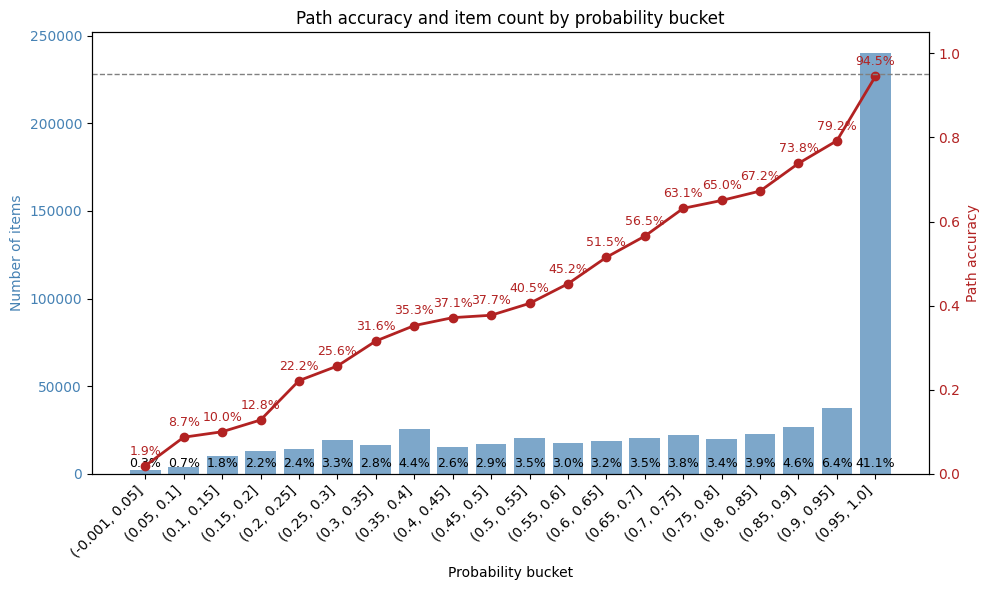

In [0]:
fig = plot_accuracy_by_bucket(overall, target_accuracy=0.95)

### Overall — accuracy against coverage

Read it as: to hit the dashed target, this is the share of products that
can be classified without review.

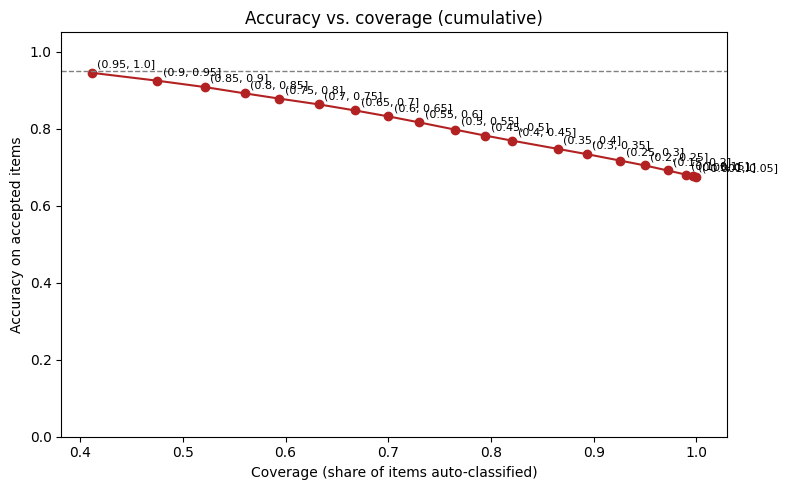

In [0]:
fig = plot_coverage_curve(overall, target_accuracy=0.95)

### By level — accuracy and volume

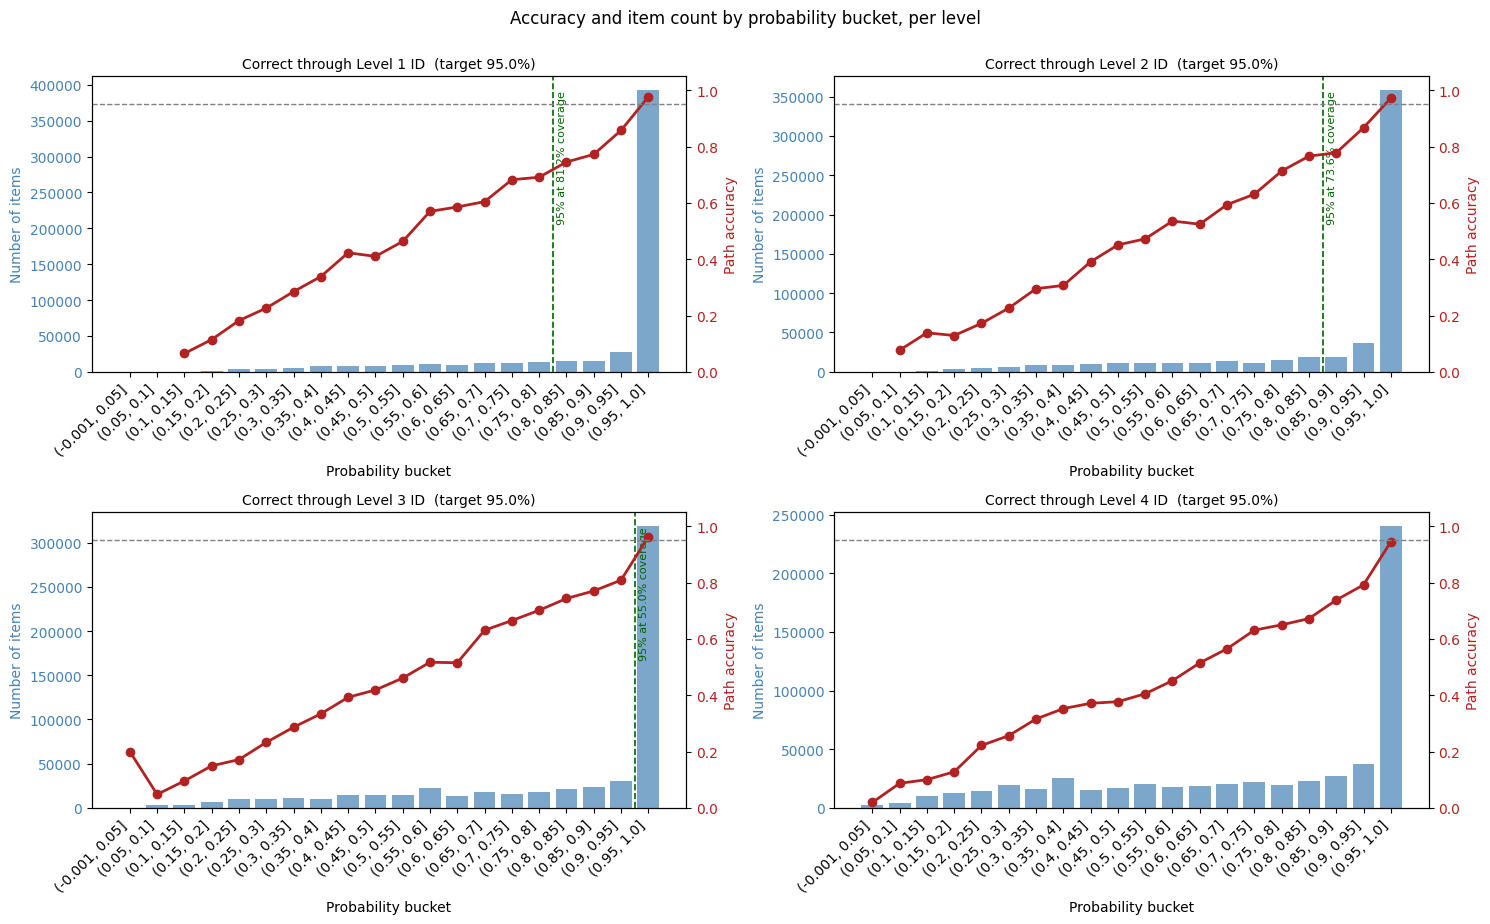

In [0]:
fig = plot_accuracy_by_bucket_grid(summaries, level_columns=levels,
                                  target_accuracy=0.95)

### By level — coverage curves

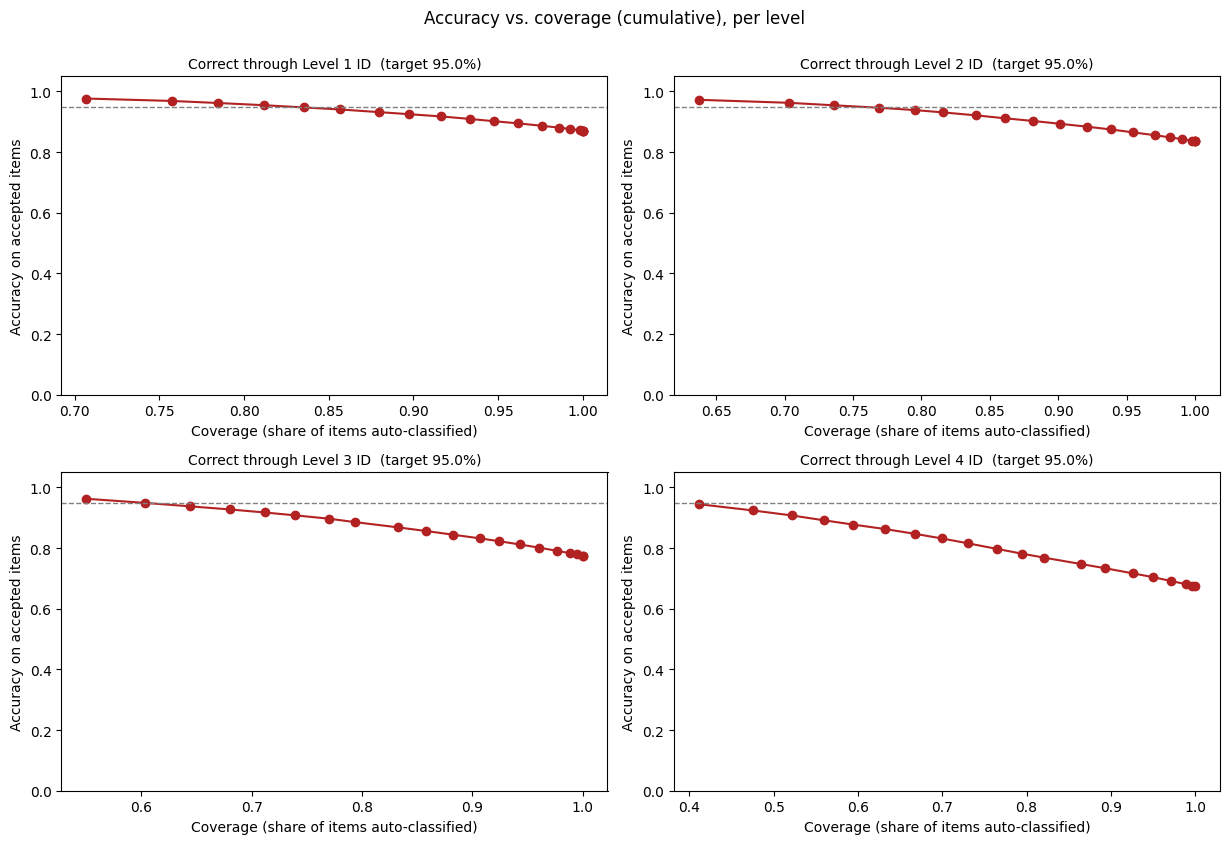

In [0]:
fig = plot_coverage_curve_grid(summaries, level_columns=levels,
                              target_accuracy=0.95)

### By level — fold spread

Mean and spread of accuracy across the folds within each bucket. Buckets
present in fewer than three folds are drawn as points: a violin over two
numbers implies a shape the data cannot support.

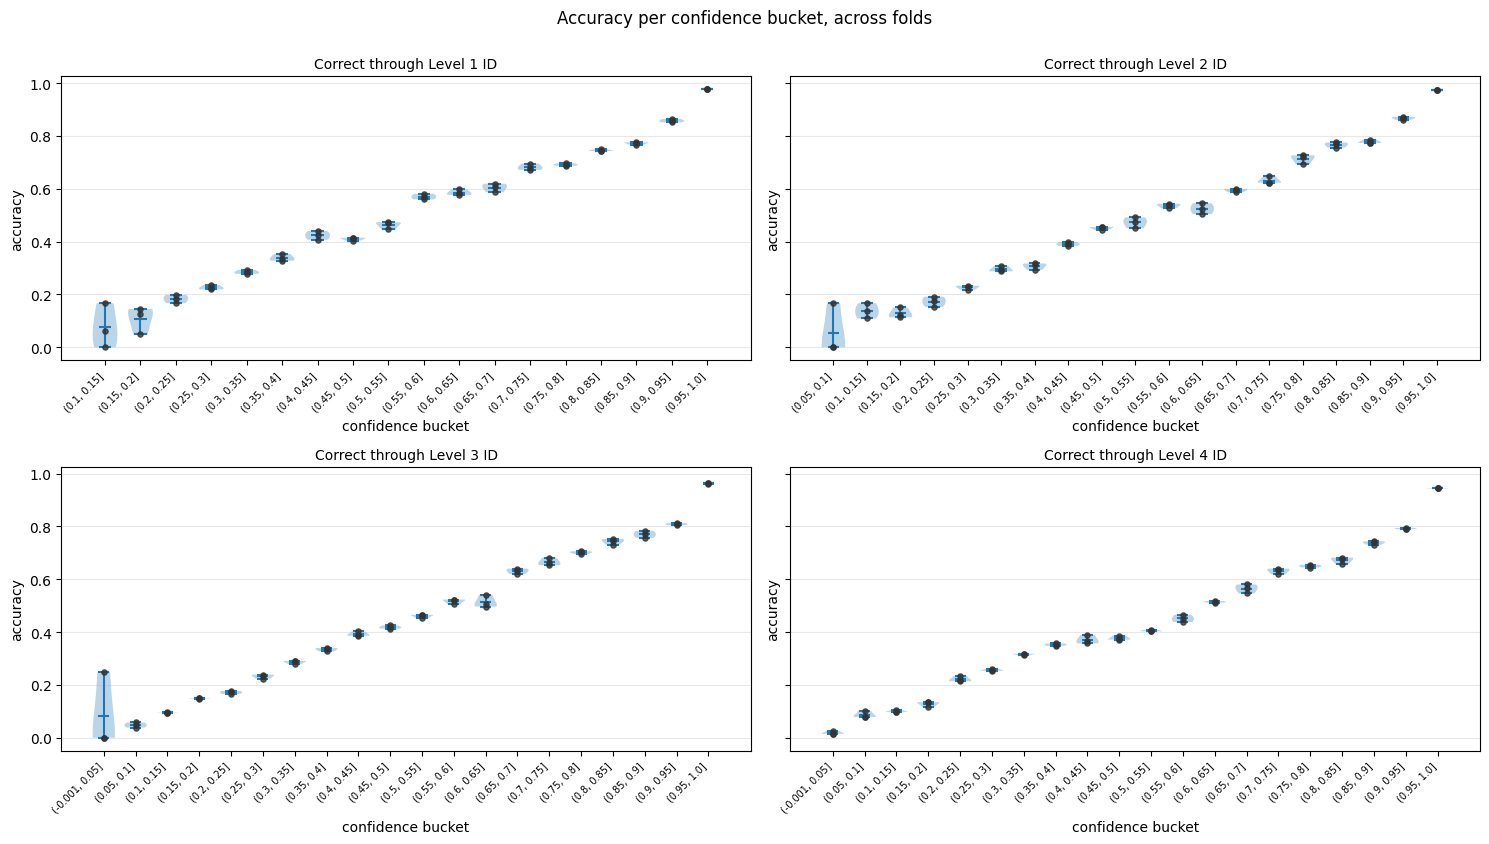

In [0]:
fig = plot_bucket_violins_by_level(by_level, level_columns=levels)

### Overall — fold spread

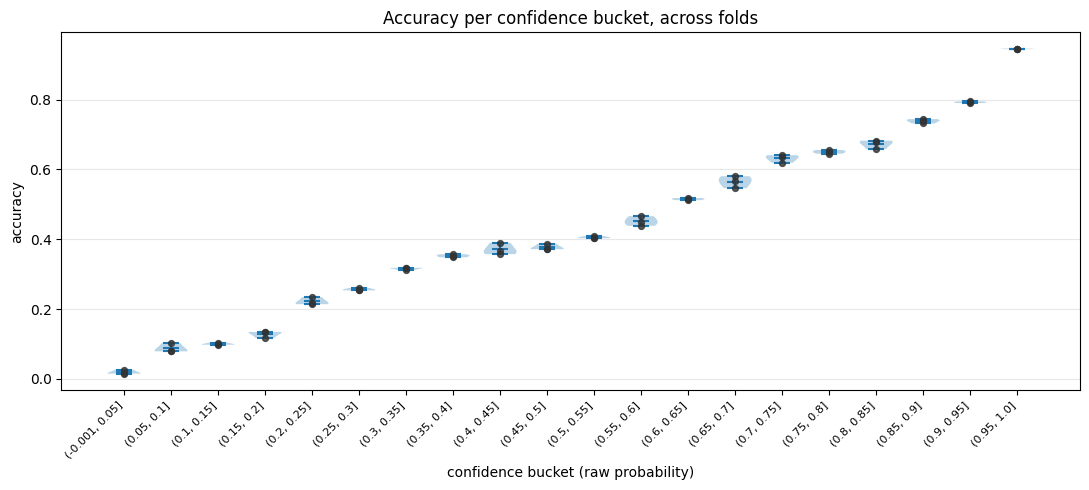

In [0]:
fig = plot_bucket_violins(by_level[by_level["depth"] == len(levels)])

### Where accuracy falls off down the hierarchy

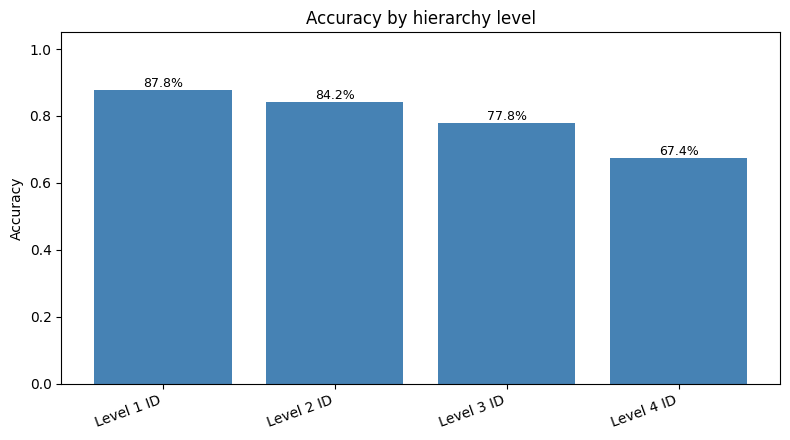

In [0]:
fig = plot_per_level_accuracy(_per_level)

### The most common mix-ups

Frequent confusions often turn out to be genuinely ambiguous or
mislabelled taxonomy nodes rather than model failures, so this tends to
feed back into the golden set rather than the model.

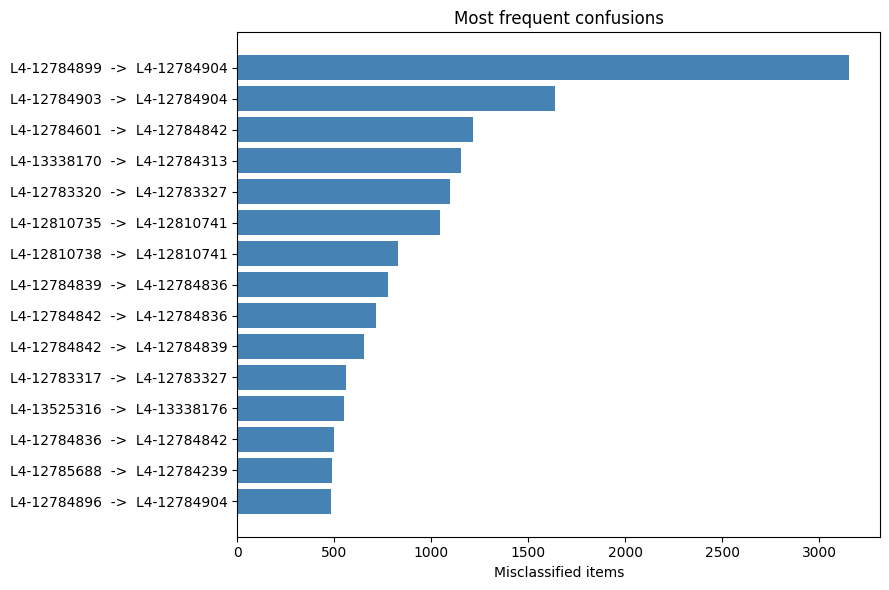

In [0]:
comparison = build_comparison(
    frame, predicted, levels, cfg.data.text_col, cfg.data.id_col
)
confusion = top_confusions(comparison, levels[-1], n=20)
fig = plot_top_confusions(confusion)

In [0]:
confusion

,Actual Level 4 ID,Predicted Level 4 ID,n
12956,L4-12784899,L4-12784904,3155
13109,L4-12784903,L4-12784904,1636
11713,L4-12784601,L4-12784842,1213
39776,L4-13338170,L4-12784313,1151
5741,L4-12783320,L4-12783327,1096
32714,L4-12810735,L4-12810741,1046
32817,L4-12810738,L4-12810741,827
11866,L4-12784839,L4-12784836,774
12041,L4-12784842,L4-12784836,716
12044,L4-12784842,L4-12784839,654


---
## 4. Determine Thresholds for Optimal Coverage

Emit the deepest level whose confidence clears its threshold, testing
deepest first; truncate rather than guess below it. Failing every
threshold means handing the product over whole, recorded as depth 0.

Two ways to set the bars. **Set `THRESHOLD_BASIS` and run one branch.**

In [0]:
THRESHOLD_BASIS = "accuracy"     # "accuracy" or "cost"

TARGET_ACCURACY = 0.95           # used when basis == "accuracy"

# used when basis == "cost": minutes of human work still needed after the
# model answers to that depth. Key 0 is classifying from scratch; the
# deepest key must be 0.0.
MINUTES_BY_DEPTH = {0: 8.0, 1: 7.0, 2: 5.5, 3: 3.5, 4: 0.0}
HOURLY_RATE = 38.0               # fully loaded, not base wage
COST_OF_ERROR = 42.0             # what one wrong prefix costs downstream

costs = CostModel(MINUTES_BY_DEPTH, HOURLY_RATE, COST_OF_ERROR)
print(f"basis: {THRESHOLD_BASIS}")

basis: accuracy


### Option A — target an accuracy

One flat standard at every level. Thresholds are measured from realised
results rather than taken at face value from the model's own confidence,
which runs optimistic.

In [0]:
if THRESHOLD_BASIS == "accuracy":
    assigned, thresholds, fold_thresholds = crossfit_accuracy(
        prefix, actual, levels, folds, target_accuracy=TARGET_ACCURACY,
    )
    targets = {d: TARGET_ACCURACY for d in range(1, len(levels) + 1)}
    fold_thresholds

[cv] accuracy depth_1: 0.7458-0.7468 across folds
[cv] accuracy depth_2: 0.8058-0.8077 across folds
[cv] accuracy depth_3: 0.9006-0.9019 across folds
[cv] accuracy depth_4: 0.9589-0.9603 across folds
[cv] thresholds to deploy: {1: 0.7463, 2: 0.8066, 3: 0.9008, 4: 0.9596}


### Option B — minimise cost

The thresholds are derived from the three inputs instead of chosen. Note
the shape they take: the cost view demands **more** confidence at shallow
levels, because stepping from L1 to L2 saves little staff time and so
justifies little risk. An accuracy target applies one flat bar.

In [0]:
if THRESHOLD_BASIS == "cost":
    assigned, thresholds, fold_thresholds = crossfit_cost(
        prefix, actual, levels, folds, costs,
    )
    targets = implied_accuracy_targets(costs, len(levels))
    print("\nimplied accuracy standards (marginal — the accuracy the *last*")
    print("item accepted must reach; the average will be higher):")
    for _d, _t in targets.items():
        print(f"  {levels[_d - 1]:<14} {_t:.2%}")
    display(implied_thresholds(costs, len(levels)))
    fold_thresholds

### What the thresholds deliver

Spread across folds is the thing to check. A depth whose threshold swings
between folds is being estimated from too few qualifying rows to trust —
no amount of averaging fixes that.

In [0]:
rows = []
for d in range(1, len(levels) + 1):
    s = prefix[f"L{d} Prefix Probability"].to_numpy(dtype=float)
    keep = s >= thresholds[d]
    rows.append({
        "level": levels[d - 1],
        "target": targets[d],
        "threshold": thresholds[d],
        "percentile": (s < thresholds[d]).mean(),
        "coverage": keep.mean(),
        "accuracy": prefix_correct(prefix, actual, levels, d)[keep].mean(),
    })
pd.DataFrame(rows)

,level,target,threshold,percentile,coverage,accuracy
0,Level 1 ID,0.95,0.746318,0.154860,0.845140,0.950002
1,Level 2 ID,0.95,0.806627,0.226303,0.773697,0.950000
2,Level 3 ID,0.95,0.900804,0.394618,0.605382,0.949980
3,Level 4 ID,0.95,0.959627,0.605831,0.394169,0.949997


`coverage` above is each level's **own pool**, treated independently. The
cascade assigns deepest-passing, so rows clearing depth 4 are removed from
depth 3's pool and what remains is the harder residue. Realised accuracy
at depths 1–3 in the report below therefore comes in under target. Depth 4
is unaffected, being deepest.

In [0]:
report = cascade_report(assigned, actual, levels)
print(f"mean depth (all rows): {report.attrs['mean_depth_all_rows']:.3f}")
print(f"abstain rate:          {report.attrs['abstain_rate']:.1%}")
report

mean depth (all rows): 2.618
abstain rate:          15.5%


,assigned_depth,n_items,share_of_items,accuracy
0,0,90405,0.154918,NaN
1,1,41641,0.071356,0.803775
2,2,98523,0.168829,0.877013
3,3,122717,0.210288,0.912245
4,4,230281,0.394609,0.950048


### The charts again, marked with the thresholds

Dashed horizontal is that level's target. Dashed vertical is its
threshold, rounded **up** to a bucket edge — a bucket only partly above
the threshold is excluded, so everything right of the line is accepted.

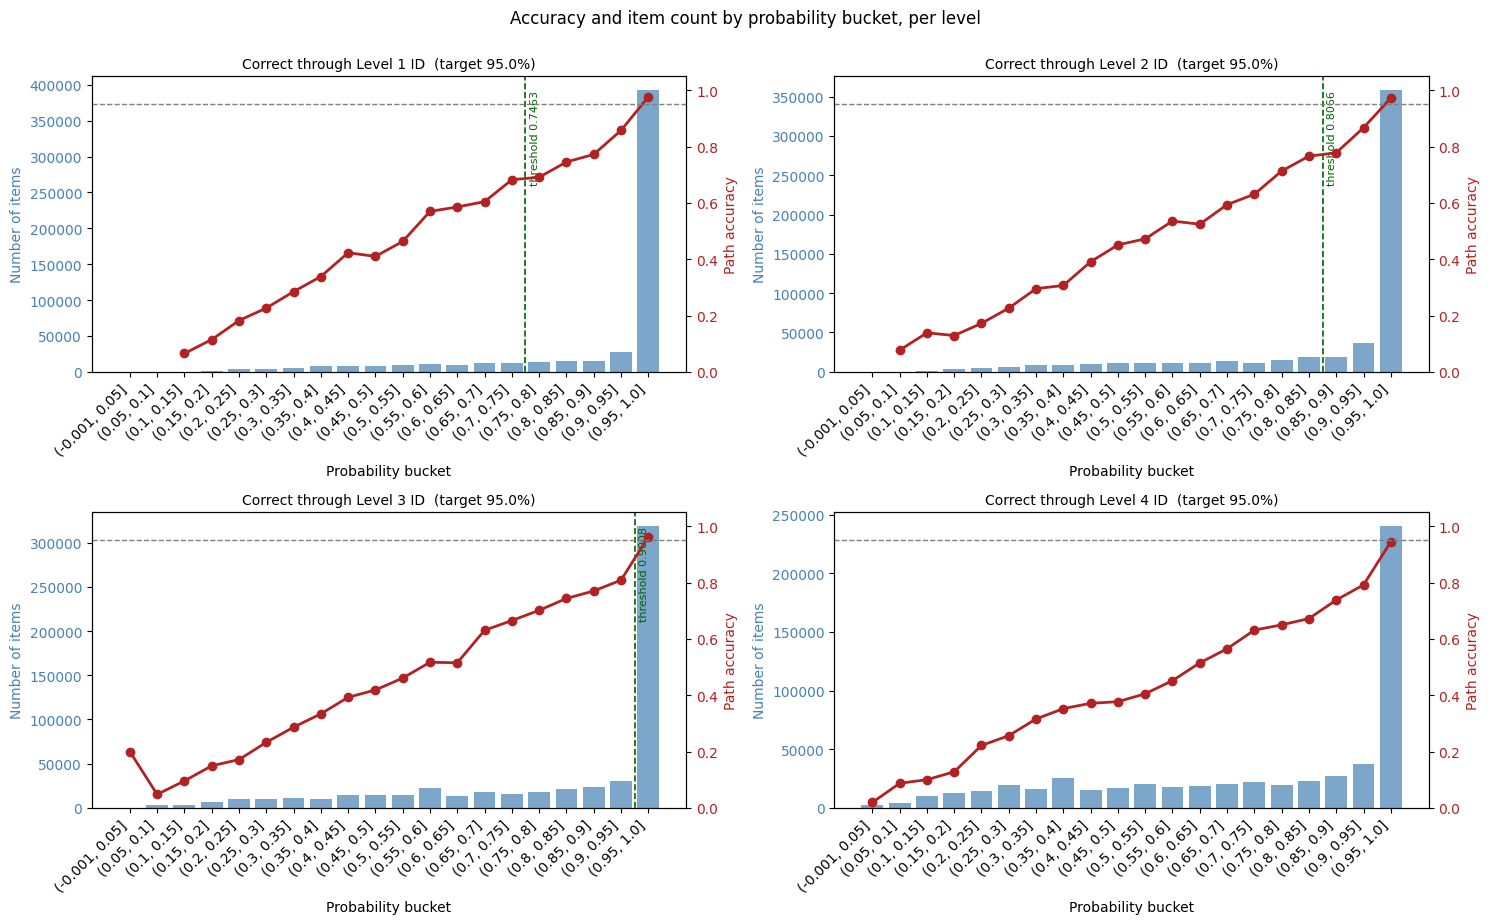

In [0]:
fig = plot_accuracy_by_bucket_grid(
    summaries, level_columns=levels,
    target_accuracy=targets, thresholds=thresholds,
)

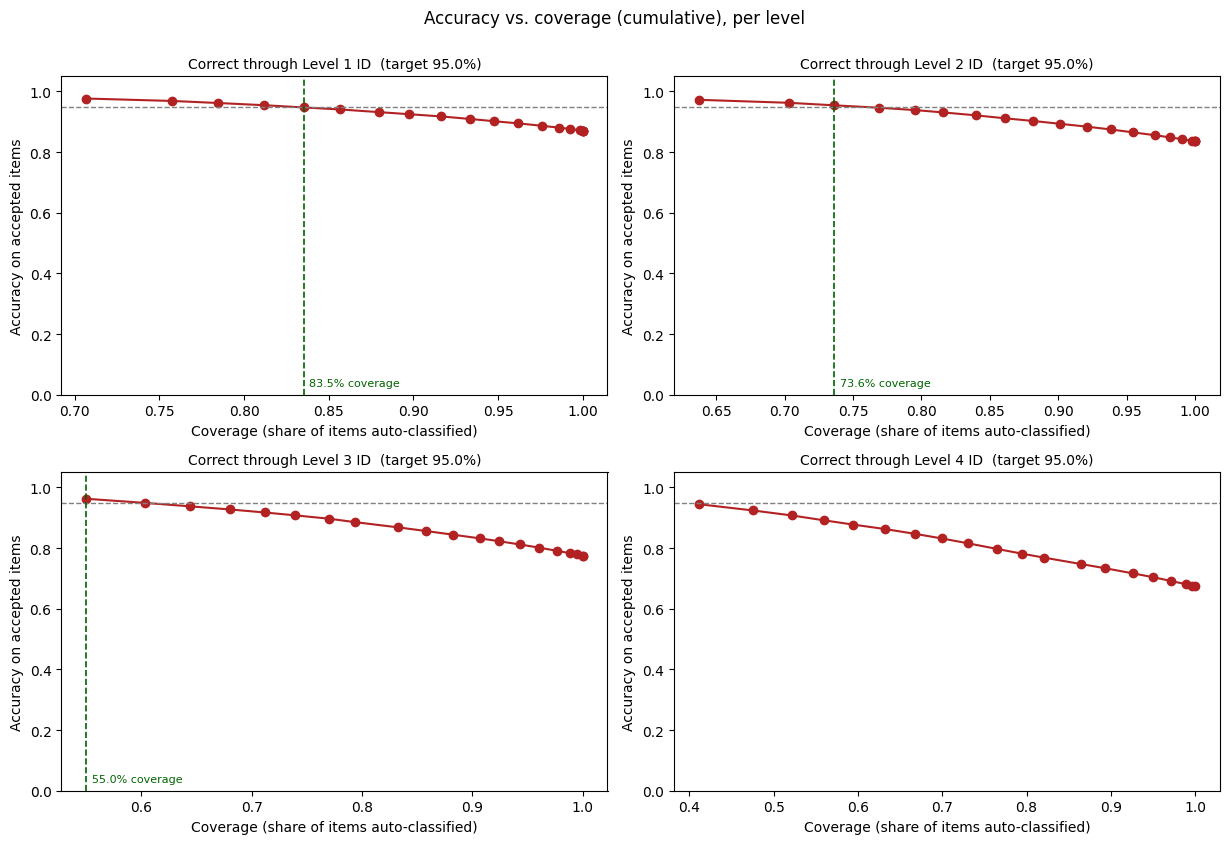

In [0]:
fig = plot_coverage_curve_grid(
    summaries, level_columns=levels,
    target_accuracy=targets, thresholds=thresholds,
)

### Every policy, priced

Including `today: all manual`, which is the number any of this has to
beat. Requires the cost inputs whichever basis you chose — they are only
used to put the policies on one scale here.

In [0]:
compare_threshold_policies(
    prefix, actual, levels, costs,
    named_thresholds={THRESHOLD_BASIS: thresholds},
)

,policy,n_items,labour_cost,error_cost,total_cost,cost_per_item,n_errors,mean_depth,excess_vs_best
0,thresholds: implied (analytic),583567,1.422644e+06,785736.0,2.208380e+06,3.784278,18708,2.253659,0.000000
1,today: all manual,583567,2.956739e+06,0.0,2.956739e+06,5.066667,0,0.000000,1.282389
2,thresholds: accuracy,583567,1.258077e+06,1788444.0,3.046521e+06,5.220517,42582,2.618388,1.436239
3,fixed: always depth 1,583567,2.587147e+06,3003756.0,5.590903e+06,9.580567,71518,1.000000,5.796290
4,fixed: always depth 2,583567,2.032758e+06,3870510.0,5.903268e+06,10.115837,92155,2.000000,6.331559
5,fixed: always depth 3,583567,1.293574e+06,5467182.0,6.760756e+06,11.585226,130171,3.000000,7.800948
6,fixed: always depth 4,583567,0.000000e+00,7981806.0,7.981806e+06,13.677617,190043,4.000000,9.893339


In [0]:
savings = savings_summary(assigned, prefix, actual, levels, costs)
print(f"products: {savings.attrs['n_items']:,} | "
      f"mean depth: {savings.attrs['mean_depth']:.2f} | "
      f"errors accepted: {savings.attrs['n_errors']:,}")
print(f"saving: {savings.attrs['saving_pct']:.1%} of the all-manual cost")
savings

products: 583,567 | mean depth: 2.62 | errors accepted: 42,560
saving: -3.0% of the all-manual cost


,measure,total,per_item
0,all manual (today),2.956739e+06,5.066667
1,with the model,3.045392e+06,5.218581
2,of which staff time,1.257872e+06,2.155488
3,of which errors,1.787520e+06,3.063093
4,saving,-8.865210e+04,-0.151914


### Is the error cost doing any work?

`cost_of_error` is the input nobody can measure, so rather than defending
a number, check whether it changes anything. If mean depth barely moves
across a wide range, the choice is immaterial.

In [0]:
sweep_error_cost(prefix, actual, levels, costs,
                 error_costs=(50, 100, 250))

,cost_of_error,threshold_depth_1,threshold_depth_2,threshold_depth_3,threshold_depth_4,mean_depth,n_errors,cost_per_item
0,50,0.999832,0.998350,0.994742,0.991252,1.737800,6240,3.622575
1,100,0.999927,0.999510,0.999107,0.998121,1.372740,2585,3.989469
2,250,0.999987,0.999922,0.999864,0.999662,0.976818,884,4.394158


---
## 5. Per-item answers

`Auto Accept` is the yes/no: the model went all the way, nobody needs to
look. Otherwise `Levels Left To Do` is the work remaining.

In [0]:
per_item = per_item_table(
    assigned, frame, levels, cfg.data.text_col, cfg.data.id_col,
    prefix_df=prefix, actual=actual,
)
per_item.head(20)

,Vallen ID,FullDesc,Level 1 ID,Level 2 ID,Level 3 ID,Level 4 ID,Assigned Depth,Assigned Probability,Auto Accept,Levels Left To Do,Outcome,Prefix Correct
0,00892502046,BLADE TH,L1-12810533,,,,1,0.811066,False,3,partial - human completes,1.0
1,00892538579,ROUTER BIT,L1-12783695,L2-12783697,L3-12783722,,3,0.908400,False,1,partial - human completes,1.0
2,008925DS0912BW5,DEMON,L1-12810533,L2-12810536,,,2,0.878600,False,2,partial - human completes,1.0
3,01011981-34-34,MAGNIFIER ILLUM,L1-12798733,,,,1,0.973795,False,3,partial - human completes,0.0
4,01058203068,BLOCK GABLE,,,,,0,0.000000,False,4,hand over entirely,NaN
5,15544235,WHEEL,L1-12783670,,,,1,0.900171,False,3,partial - human completes,1.0
6,01181200949,BRUSH SS,L1-12783670,L2-12783671,L3-12783674,,3,0.929353,False,1,partial - human completes,1.0
7,01181214610,BRUSH TUBE BRASS LONG HANDLE OAL,L1-12783670,L2-12783671,L3-12783674,L4-12784258,4,0.982246,True,0,auto-accept,1.0
8,01181243407,BRUSH CONDENSER SS,L1-12783670,L2-12783671,L3-12783674,L4-12784259,4,0.963099,True,0,auto-accept,1.0
9,01238200134,NRW CRMP WIRE WHEEL,L1-12783670,L2-12783671,L3-12783674,L4-12784260,4,0.999924,True,0,auto-accept,1.0


In [0]:
outcome_summary(per_item)

,outcome,n_items,share,accuracy
0,partial - human completes,262881,0.450473,0.881859
1,auto-accept,230281,0.394609,0.950048
2,hand over entirely,90405,0.154918,NaN


---
## 6. Save

In [0]:
THRESHOLDS_PATH = "../outputs/thresholds.json"
PER_ITEM_PATH = "../outputs/per_item_crossval.csv"

record = {
    "basis": THRESHOLD_BASIS,
    "thresholds": {str(d): float(t) for d, t in thresholds.items()},
    "targets": {str(d): float(t) for d, t in targets.items()},
    "n_folds": N_FOLDS,
    "n_rows": int(len(prefix)),
    "min_path_count": cfg.split.min_path_count,
    "mean_depth": float(report.attrs["mean_depth_all_rows"]),
    "abstain_rate": float(report.attrs["abstain_rate"]),
    "scale": "raw (uncalibrated)",
}
if THRESHOLD_BASIS == "cost":
    record["cost_model"] = {
        "minutes_by_depth": {str(k): v for k, v in MINUTES_BY_DEPTH.items()},
        "hourly_rate": HOURLY_RATE,
        "cost_of_error": COST_OF_ERROR,
    }

os.makedirs("../outputs", exist_ok=True)
with open(THRESHOLDS_PATH, "w", encoding="utf-8") as fh:
    json.dump(record, fh, indent=2)
per_item.to_csv(PER_ITEM_PATH, index=False)

print(f"wrote {THRESHOLDS_PATH}")
print(f"wrote {PER_ITEM_PATH}")
print(json.dumps(record, indent=2))

wrote ../outputs/thresholds.json
wrote ../outputs/per_item_crossval.csv
{
  "basis": "accuracy",
  "thresholds": {
    "1": 0.7463183740487414,
    "2": 0.8066273511585061,
    "3": 0.9008043945741885,
    "4": 0.9596265114583468
  },
  "targets": {
    "1": 0.95,
    "2": 0.95,
    "3": 0.95,
    "4": 0.95
  },
  "n_folds": 3,
  "n_rows": 583567,
  "min_path_count": 5,
  "mean_depth": 2.618314606549034,
  "abstain_rate": 0.1549179442977413,
  "scale": "raw (uncalibrated)"
}
